<a href="https://colab.research.google.com/github/yordanET/ExamenPractico2MD/blob/main/ExamenPractico2MD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#add libraries
import pandas as pd #for data manipulation and analysis(para manipulación y análisis de datos)
import numpy as np # for numeriacal operations(para operaciones numéricas)
import matplotlib.pyplot as plt #for data vizualization using charts(para visualización de datos mediante gráficos)
import seaborn as sns #for stadistical data vizualization(para la visualización de datos estadísticos)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# **EXTRACCION DE DATOS**


In [10]:
# Define dataset paths
path_academico = "/content/drive/MyDrive/clases-2026-1/mineria/segunda_unidad/ex/dataset_academico.csv"
path_psicosocial = "/content/drive/MyDrive/clases-2026-1/mineria/segunda_unidad/ex/dataset_psicosocial.csv"

In [11]:
# Load academic dataset
df_academico = pd.read_csv(path_academico)

In [12]:
# Load psychosocial dataset
df_psicosocial = pd.read_csv(path_psicosocial)

In [13]:
# Display dataset dimensions
print("Academic dataset shape:", df_academico.shape)
print("Psychosocial dataset shape:", df_psicosocial.shape)

Academic dataset shape: (3000, 17)
Psychosocial dataset shape: (3000, 20)


In [14]:
# Display first rows of each dataset
display(df_academico.head())
display(df_psicosocial.head())

,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,num_inasistencias_injustificadas,tendencia_notas,participacion_clase,entrega_tareas,repitio_grado,horas_estudio_semanal,target
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,1,Empeorando,Media,64.4,1,3.9,Continua_estudiando
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,0,Mejorando,Media,100.0,0,12.8,Continua_estudiando
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,2,Estable,Alta,77.5,0,13.8,Continua_estudiando
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,5,NaN,Alta,73.1,1,16.1,Continua_estudiando
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,2,Estable,Media,92.9,0,12.9,Continua_estudiando


,id_estudiante,genero,estructura_familiar,num_hermanos,nivel_socioeconomico,nivel_educativo_padres,trabaja_estudiante,horas_trabajo_semanal,acceso_internet_hogar,distancia_colegio_km,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,2467,Femenino,Un solo padre,3,Medio,Superior,0,NaN,1,6.61,4.0,3,4,3,0,Regular,7.4,0,0,0
1,3555,Masculino,Ambos padres,2,Medio,Superior,0,NaN,0,0.87,NaN,3,4,2,0,Regular,8.3,0,0,0
2,3064,Masculino,Ambos padres,0,Alto,Secundaria,0,NaN,1,0.28,3.0,3,1,5,0,Buena,5.6,0,1,0
3,1189,Femenino,Otros familiares,3,Medio-bajo,Secundaria,1,16.2,1,4.02,3.0,3,3,3,0,Regular,6.9,0,0,0
4,3779,Masculino,Ambos padres,0,Medio,Superior,0,NaN,1,3.51,5.0,3,4,4,0,Buena,7.5,1,0,0


In [15]:
# Merge both datasets using the student ID
df = pd.merge(
    df_academico,
    df_psicosocial,
    on="id_estudiante",
    how="inner"
)

In [16]:
# Display merged dataset dimensions
print("Merged dataset shape:", df.shape)

Merged dataset shape: (3000, 36)


In [17]:
# Display first rows of merged dataset
display(df.head())

,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,...,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,...,5.0,1,4,4,0,Regular,7.2,0,1,1
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,...,3.0,2,5,3,0,Regular,7.9,0,0,0
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,...,3.0,2,5,4,0,Regular,6.7,0,0,0
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,...,5.0,2,3,3,0,Buena,5.2,0,1,0
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,...,4.0,2,3,4,0,Buena,6.8,0,1,0


# **EDA**

In [20]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 3000
Columns: 36


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id_estudiante                            3000 non-null   int64  
 1   edad                                     3000 non-null   float64
 2   grado                                    3000 non-null   int64  
 3   promedio_matematica                      3000 non-null   float64
 4   promedio_comunicacion                    3000 non-null   float64
 5   promedio_ciencias                        2910 non-null   float64
 6   promedio_general                         3000 non-null   float64
 7   num_cursos_desaprobados                  3000 non-null   int64  
 8   porcentaje_asistencia                    2940 non-null   float64
 9   num_tardanzas                            3000 non-null   int64  
 10  num_inasistencias_injustificadas         3000 no

In [22]:
# Preview dataset contents
display(df.head())

,id_estudiante,edad,grado,promedio_matematica,promedio_comunicacion,promedio_ciencias,promedio_general,num_cursos_desaprobados,porcentaje_asistencia,num_tardanzas,...,nivel_autoestima,nivel_ansiedad,nivel_motivacion_escolar,apoyo_familiar_percibido,eventos_estresantes_recientes,relacion_con_companeros,horas_sueño_diarias,consumo_sustancias,participa_actividades_extracurriculares,atencion_psicologica_previa
0,3169,16.0,5,10.85,14.06,12.30,13.37,0,77.5,6,...,5.0,1,4,4,0,Regular,7.2,0,1,1
1,1163,15.0,3,18.63,14.59,16.66,17.37,0,100.0,1,...,3.0,2,5,3,0,Regular,7.9,0,0,0
2,2517,13.0,2,20.00,16.54,14.42,16.74,0,98.5,2,...,3.0,2,5,4,0,Regular,6.7,0,0,0
3,2318,13.0,1,16.91,19.40,19.70,18.24,1,95.4,1,...,5.0,2,3,3,0,Buena,5.2,0,1,0
4,1686,17.0,5,17.83,13.27,14.91,15.59,0,87.4,2,...,4.0,2,3,4,0,Buena,6.8,0,1,0


In [23]:
# Summarize numerical variables
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id_estudiante,3000.0,2500.500000,866.169729,1001.00,1750.7500,2500.500,3250.2500,4000.00
edad,3000.0,14.462667,1.550723,6.00,13.0000,14.000,16.0000,30.00
grado,3000.0,2.958333,1.412774,1.00,2.0000,3.000,4.0000,5.00
promedio_matematica,3000.0,12.209660,4.058927,0.00,9.2375,12.240,15.2125,20.00
promedio_comunicacion,3000.0,12.295623,4.087180,0.00,9.4000,12.355,15.4000,20.00
promedio_ciencias,2910.0,12.389969,4.126823,0.00,9.4800,12.490,15.5200,20.00
promedio_general,3000.0,12.312043,3.605354,2.14,9.6175,12.395,15.1600,20.00
num_cursos_desaprobados,3000.0,1.882000,1.768932,0.00,0.0000,2.000,3.0000,9.00
porcentaje_asistencia,2940.0,78.370748,12.408769,31.60,69.9000,78.700,87.7250,112.70
num_tardanzas,3000.0,4.870000,3.554431,0.00,2.0000,4.000,7.0000,57.00


In [24]:
# SUMMARIZE CATEGORICAL VARIABLES
display(df.describe(include='object').T)

,count,unique,top,freq
tendencia_notas,2880,3,Mejorando,1018
participacion_clase,3000,3,Media,1142
target,3000,3,Necesita_reforzamiento,1196
genero,3000,3,Masculino,1436
estructura_familiar,3000,4,Ambos padres,1611
nivel_socioeconomico,2880,4,Medio,1140
nivel_educativo_padres,2850,4,Secundaria,1245
relacion_con_companeros,2910,3,Regular,1254


In [25]:
df.isnull().sum()

,0
id_estudiante,0
edad,0
grado,0
promedio_matematica,0
promedio_comunicacion,0
promedio_ciencias,90
promedio_general,0
num_cursos_desaprobados,0
porcentaje_asistencia,60
num_tardanzas,0


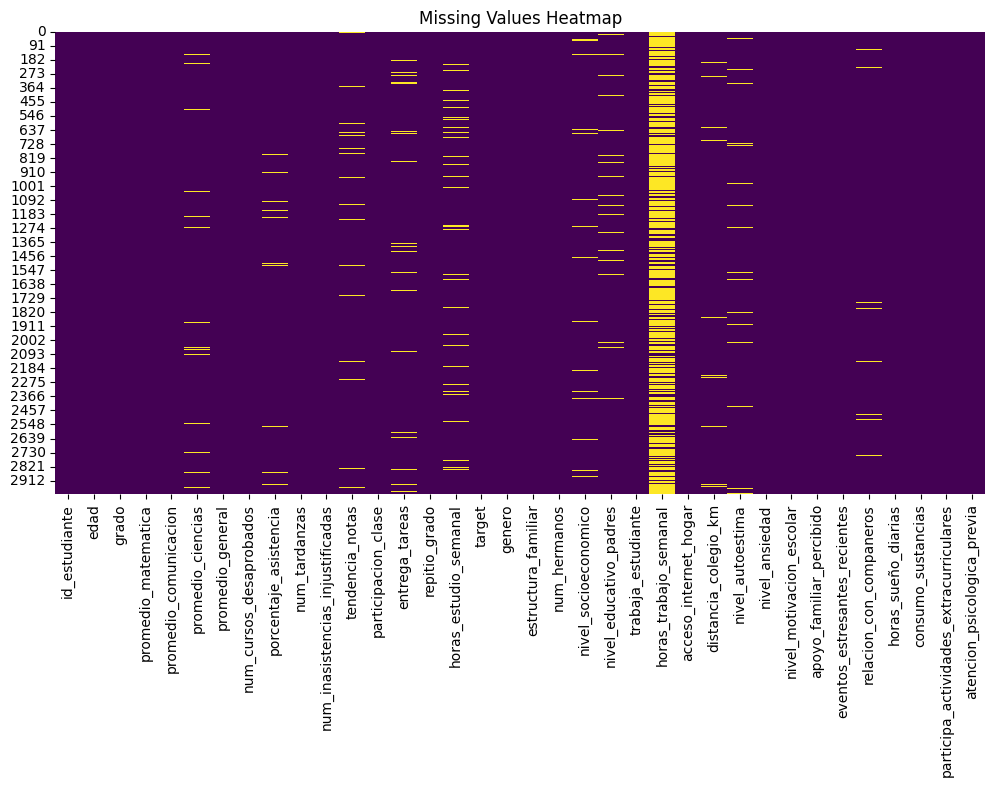

In [26]:
# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [28]:
# Identify duplicated rows
duplicates = df.duplicated().sum()
print(f"Duplicated: {duplicates}")

Duplicated: 0


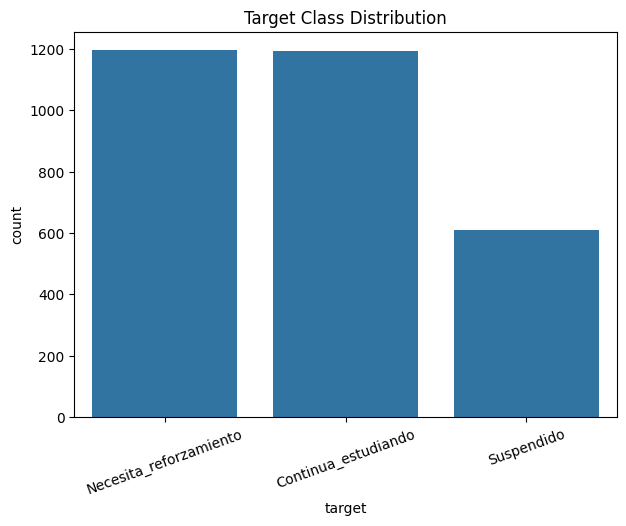

In [31]:

# ANALYZE TARGET DISTRIBUTION

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x='target',
              order=df['target'].value_counts().index)

plt.title("Target Class Distribution")
plt.xticks(rotation=20)

plt.show()



In [33]:
display(df['target'].value_counts())

,count
target,
Necesita_reforzamiento,1196
Continua_estudiando,1195
Suspendido,609


In [34]:
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES

numeric_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(include='object').columns

print("Numerical Features")
print(numeric_columns.tolist())

print()

print("Categorical Features")
print(categorical_columns.tolist())

Numerical Features
['id_estudiante', 'edad', 'grado', 'promedio_matematica', 'promedio_comunicacion', 'promedio_ciencias', 'promedio_general', 'num_cursos_desaprobados', 'porcentaje_asistencia', 'num_tardanzas', 'num_inasistencias_injustificadas', 'entrega_tareas', 'repitio_grado', 'horas_estudio_semanal', 'num_hermanos', 'trabaja_estudiante', 'horas_trabajo_semanal', 'acceso_internet_hogar', 'distancia_colegio_km', 'nivel_autoestima', 'nivel_ansiedad', 'nivel_motivacion_escolar', 'apoyo_familiar_percibido', 'eventos_estresantes_recientes', 'horas_sueño_diarias', 'consumo_sustancias', 'participa_actividades_extracurriculares', 'atencion_psicologica_previa']

Categorical Features
['tendencia_notas', 'participacion_clase', 'target', 'genero', 'estructura_familiar', 'nivel_socioeconomico', 'nivel_educativo_padres', 'relacion_con_companeros']


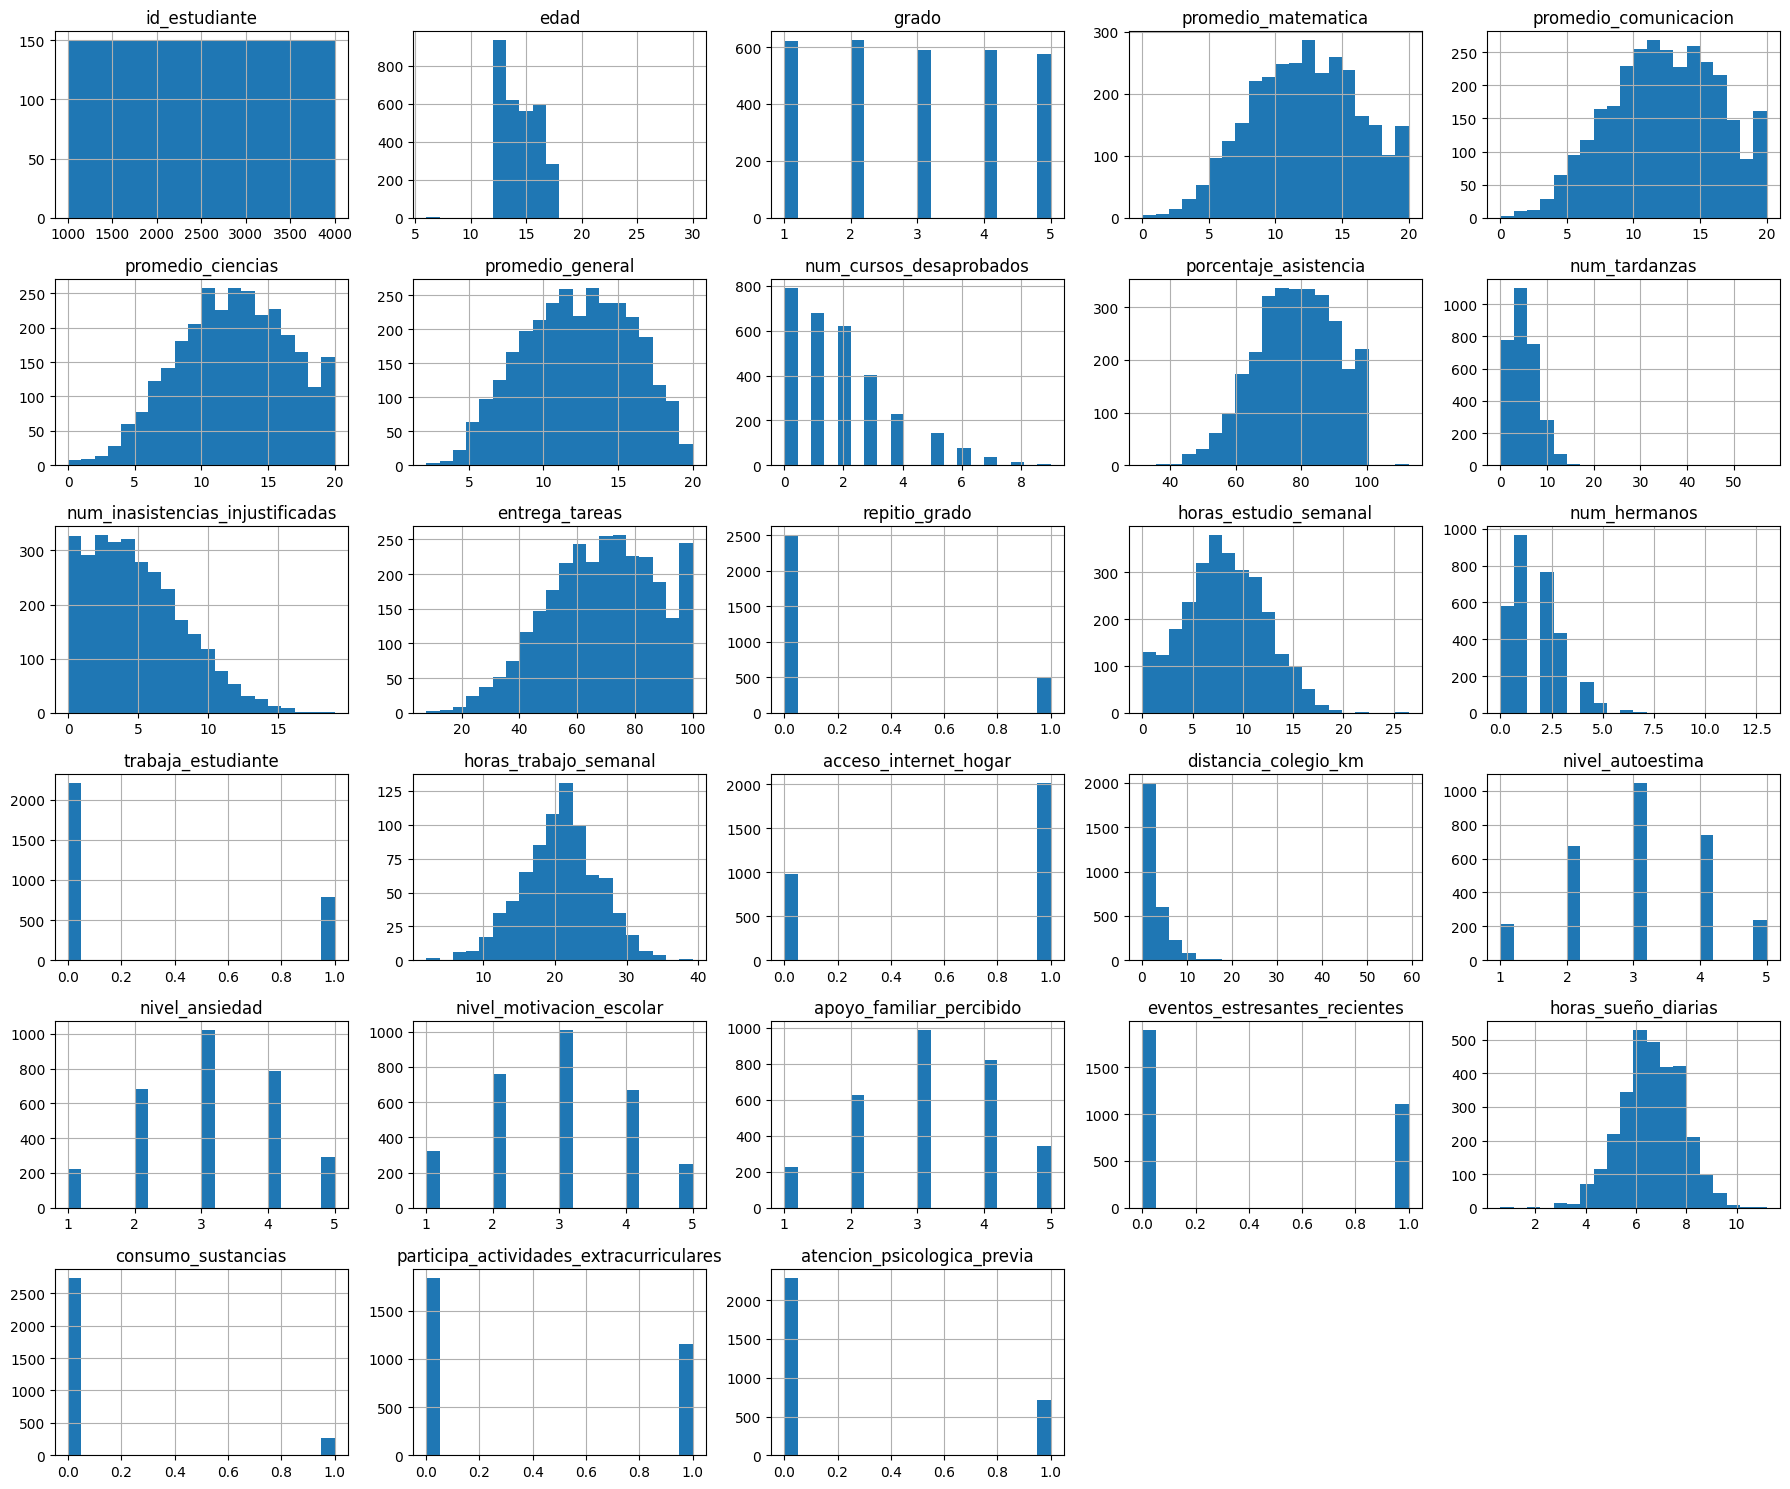

In [35]:
# VISUALIZE NUMERICAL FEATURES

df[numeric_columns].hist(
    figsize=(18,15),
    bins=20
)

plt.tight_layout()

plt.show()

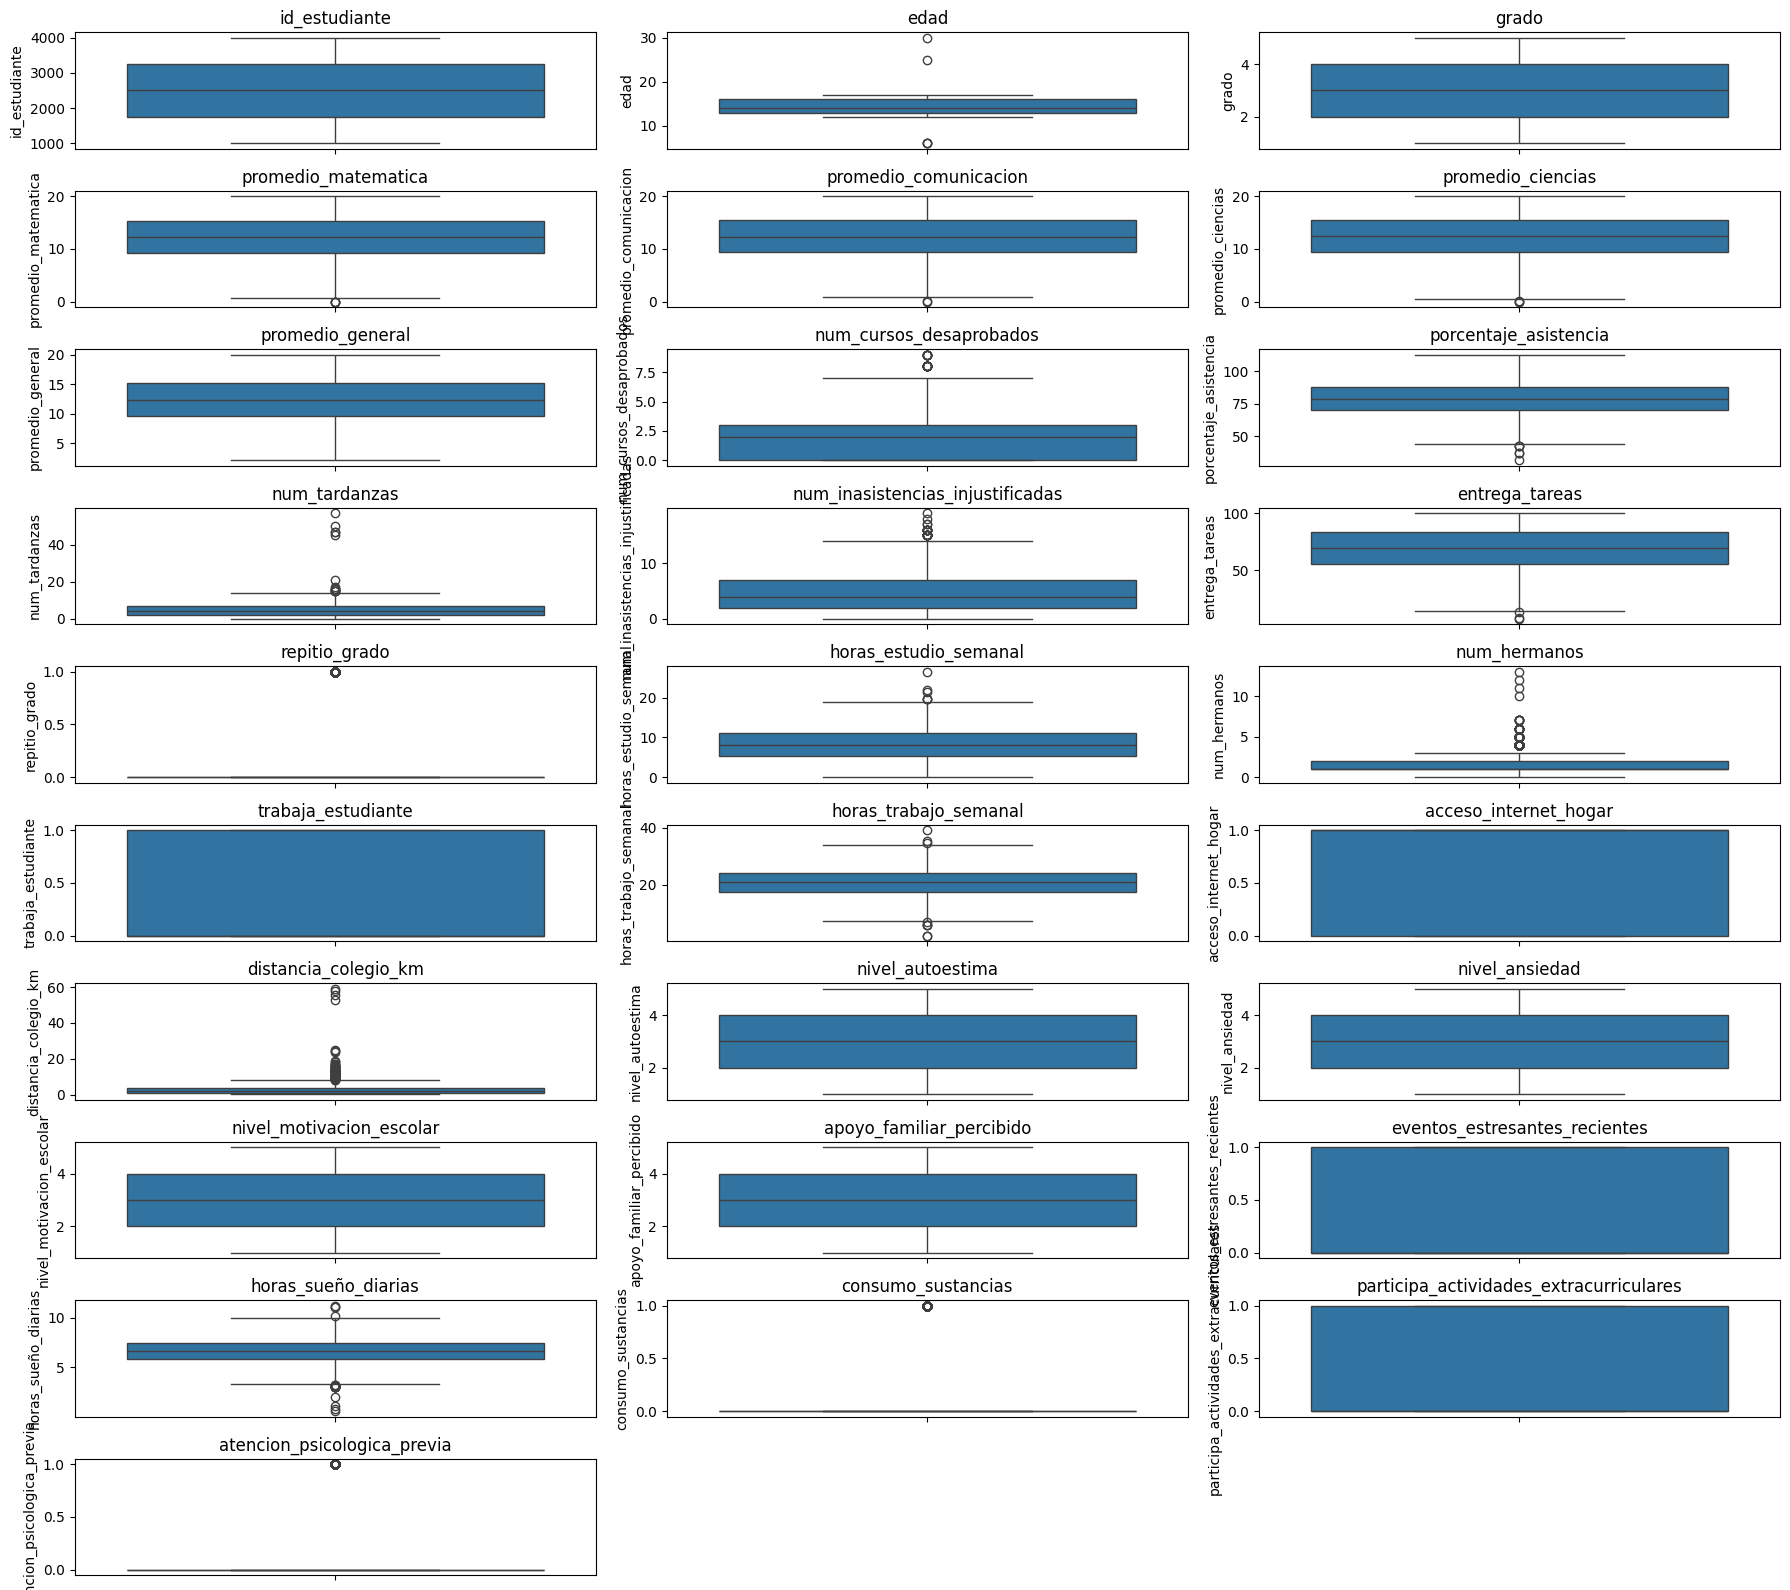

In [36]:
# DETECT OUTLIERS USING BOXPLOTS

plt.figure(figsize=(18,16))

for i,col in enumerate(numeric_columns):

    plt.subplot((len(numeric_columns)+2)//3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

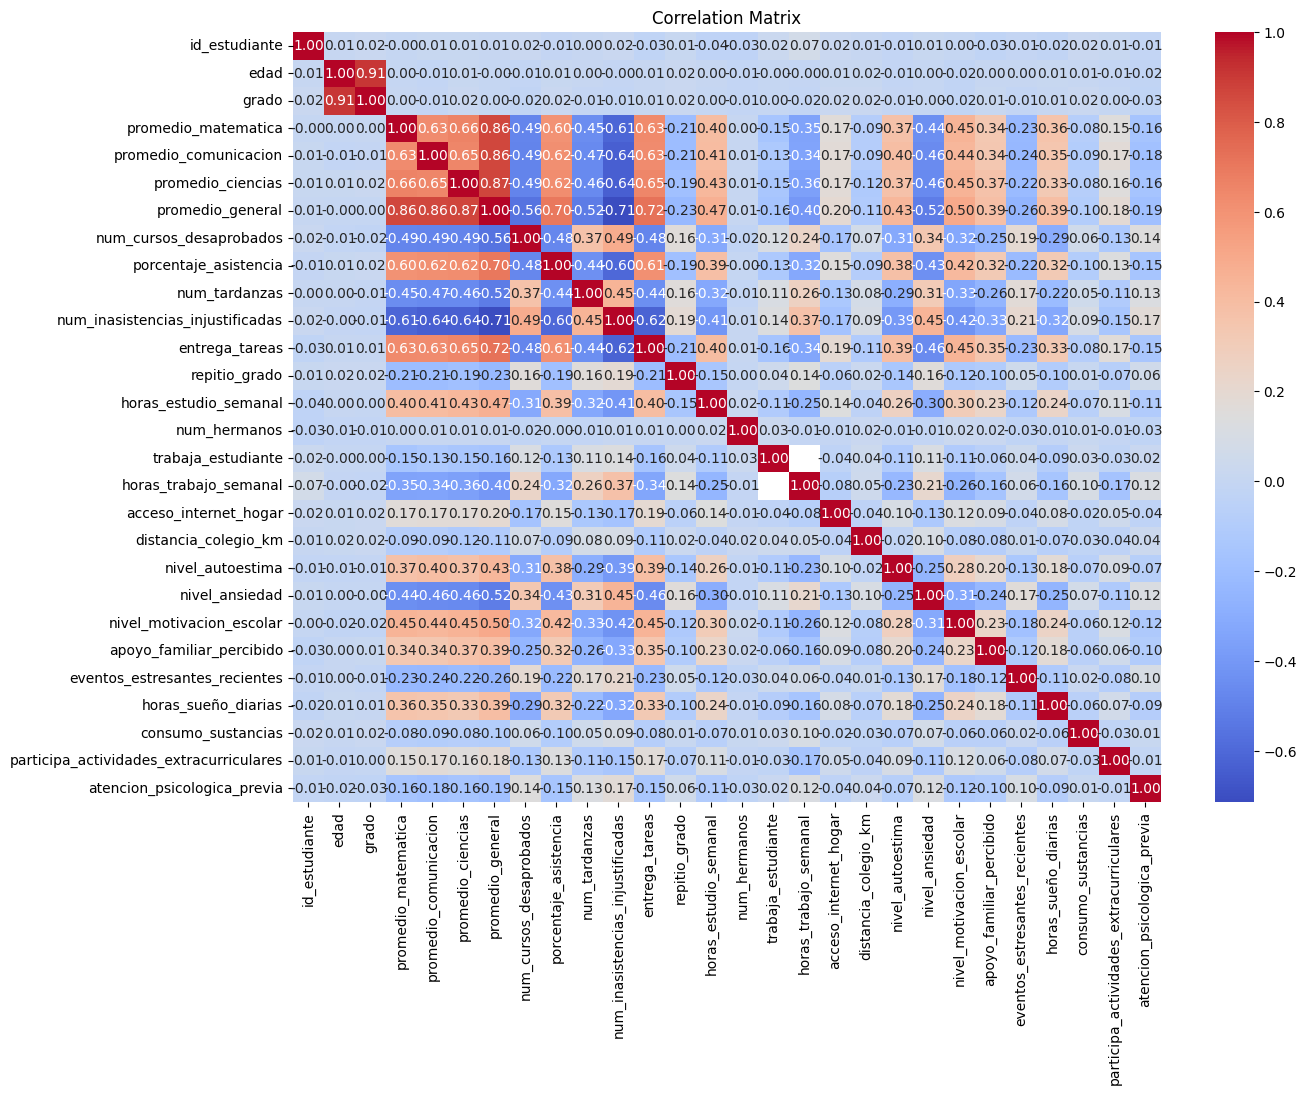

In [37]:
# ANALYZE FEATURE CORRELATION
plt.figure(figsize=(14,10))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

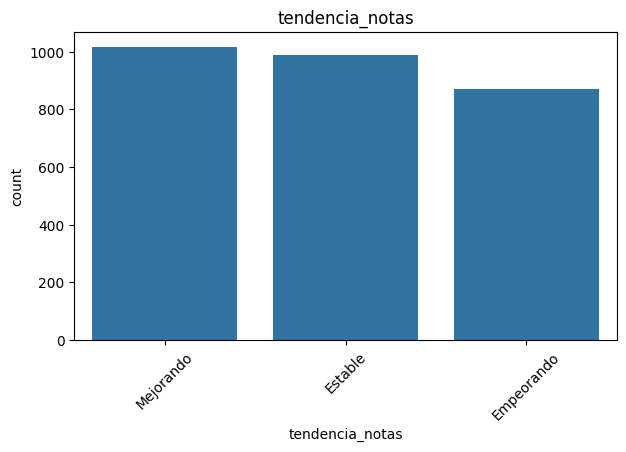

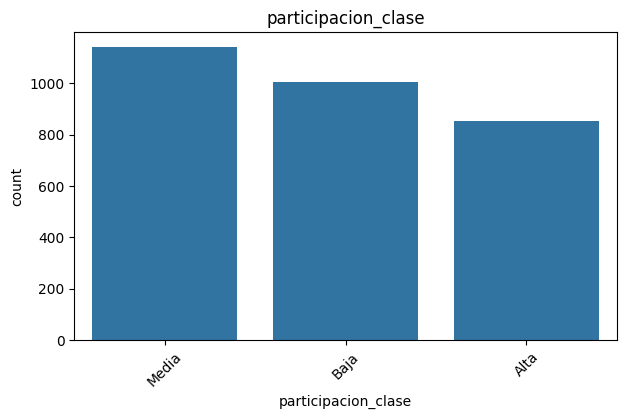

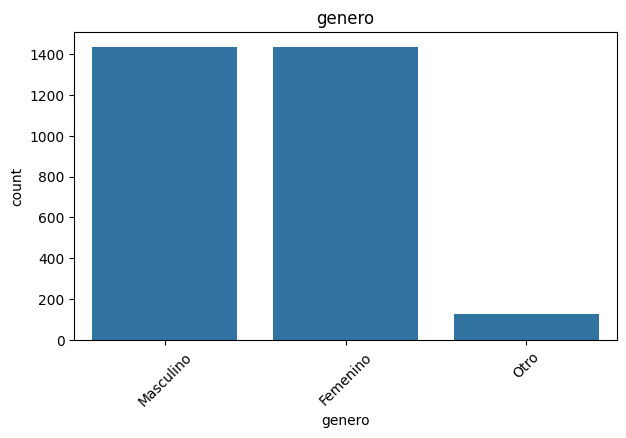

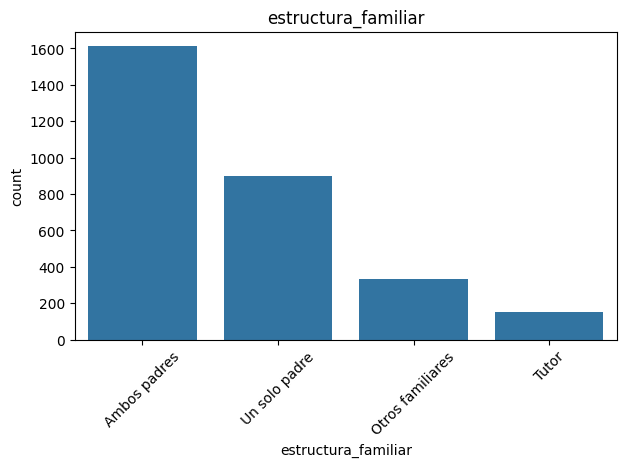

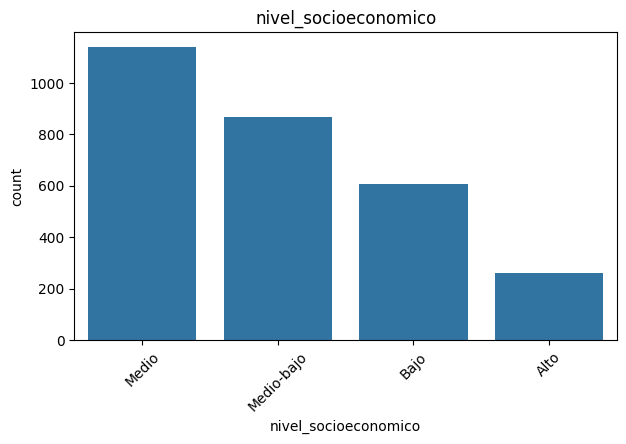

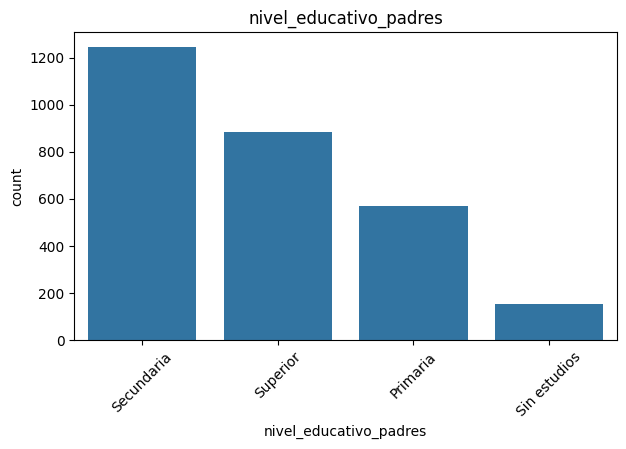

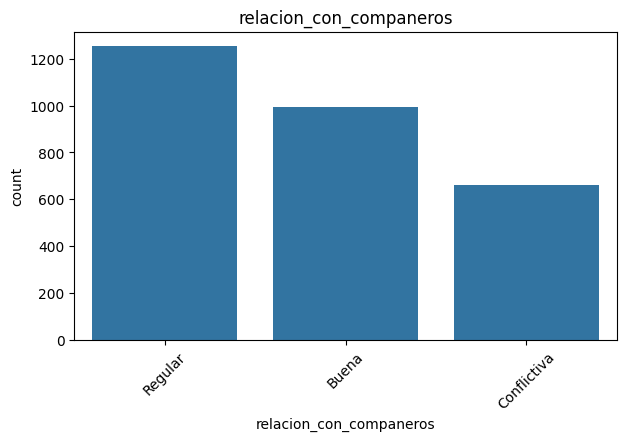

In [38]:
# VISUALIZE CATEGORICAL VARIABLES

for col in categorical_columns:

    if col != "target":

        plt.figure(figsize=(7,4))

        sns.countplot(data=df,
                      x=col,
                      order=df[col].value_counts().index)

        plt.xticks(rotation=45)

        plt.title(col)

        plt.show()

# **PREPROCESAMIENTO**

In [39]:
# REMOVE DUPLICATED RECORDS

print(f"Rows before: {df.shape[0]}")

df.drop_duplicates(inplace=True)

print(f"Rows after: {df.shape[0]}")

Rows before: 3000
Rows after: 3000


In [40]:
# Fill numerical variables with median
for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical variables with mode
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2291/3078882668.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2291/3078882668.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [41]:
# HANDLE OUTLIERS USING IQR

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [42]:
# Convert Yes/No variables into numeric values
binary_map = {
    "Si":1,
    "Sí":1,
    "No":0
}

df.replace(binary_map, inplace=True)

In [43]:
# Convert ordinal categories into ordered numerical values

df["participacion_clase"] = df["participacion_clase"].map({
    "Baja":1,
    "Media":2,
    "Alta":3
})

df["tendencia_notas"] = df["tendencia_notas"].map({
    "Empeorando":1,
    "Estable":2,
    "Mejorando":3
})

df["nivel_socioeconomico"] = df["nivel_socioeconomico"].map({
    "Bajo":1,
    "Medio-bajo":2,
    "Medio":3,
    "Alto":4
})

df["nivel_educativo_padres"] = df["nivel_educativo_padres"].map({
    "Sin estudios":1,
    "Primaria":2,
    "Secundaria":3,
    "Superior":4
})

In [44]:
# APPLY ONE-HOT ENCODING

nominal_cols = [
    "genero",
    "estructura_familiar",
    "relacion_con_companeros"
]

df = pd.get_dummies(
    df,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)

In [45]:
# Convert target classes into numerical labels

target_map = {
    "Continua_estudiando":0,
    "Necesita_reforzamiento":1,
    "Suspendido":2
}

df["target"] = df["target"].map(target_map)

In [72]:
# Download preprocessed dataset
df.to_csv('preprocessed_dataset.csv', index=False)
from google.colab import files
files.download('preprocessed_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Division de datos**

In [46]:
# Separate predictors from target


X = df.drop(columns=["target"])

y = df["target"]

In [47]:
# Standardize numerical features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = X.select_dtypes(include=np.number).columns

X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [49]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
# Verify the size of each dataset

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2400, 39)
X_test shape: (600, 39)
y_train shape: (2400,)
y_test shape: (600,)


# **Modelos ML**

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [52]:
#model svm
svm_model = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    random_state=42
)

In [53]:
#model RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [54]:
#model DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# **Entrenamiento**

In [55]:
#train model svm
svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [56]:
#train model RandomForestClassifier
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [57]:
#train model DecisionTreeClassifier
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# **Resultados**

In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [66]:
#Accuracy train and test svm
y_pred_train_svm = svm_model.predict(X_train)
y_pred_test_svm = svm_model.predict(X_test)

accuracy_train_svm = accuracy_score(y_train, y_pred_train_svm)
accuracy_test_svm = accuracy_score(y_test, y_pred_test_svm)

print("Accuracy Train SVM:", accuracy_train_svm)
print("Accuracy Test SVM:", accuracy_test_svm)

Accuracy Train SVM: 0.8708333333333333
Accuracy Test SVM: 0.78


In [59]:
y_pred_svm=svm_model.predict(X_test)
print("Accuracy :",accuracy_score(y_test,y_pred_svm))
print("\n Reporte : \n",classification_report(y_test,y_pred_svm))
print("\n Confusion Matrix : \n",confusion_matrix(y_test,y_pred_svm))

Accuracy : 0.78

 Reporte : 
               precision    recall  f1-score   support

           0       0.88      0.79      0.83       239
           1       0.70      0.79      0.74       239
           2       0.77      0.75      0.76       122

    accuracy                           0.78       600
   macro avg       0.79      0.77      0.78       600
weighted avg       0.79      0.78      0.78       600


 Confusion Matrix : 
 [[189  49   1]
 [ 25 188  26]
 [  0  31  91]]


In [63]:
#result the svm metrik mcc and f1 score
from sklearn.metrics import matthews_corrcoef, f1_score
mcc_svm = matthews_corrcoef(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')
print("MCC SVM:", mcc_svm)
print("F1 Score SVM:", f1_svm)

MCC SVM: 0.6583854532917244
F1 Score SVM: 0.7819894642771618


In [67]:
#Accuracy train and test rf
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)
accuracy_train_rf = accuracy_score(y_train, y_pred_train_rf)
accuracy_test_rf = accuracy_score(y_test, y_pred_test_rf)
print("Accuracy train Random Forest:", accuracy_train_rf)
print("Accuracy test Random Forest:", accuracy_test_rf)

Accuracy train Random Forest: 1.0
Accuracy test Random Forest: 0.7966666666666666


In [60]:
y_pred_rf=rf_model.predict(X_test)
print("Accuracy :",accuracy_score(y_test,y_pred_rf))
print("\n Reporte : \n",classification_report(y_test,y_pred_rf))
print("\n Confusion Matrix : \n",confusion_matrix(y_test,y_pred_rf))

Accuracy : 0.7966666666666666

 Reporte : 
               precision    recall  f1-score   support

           0       0.89      0.81      0.85       239
           1       0.73      0.79      0.76       239
           2       0.78      0.80      0.79       122

    accuracy                           0.80       600
   macro avg       0.80      0.80      0.80       600
weighted avg       0.80      0.80      0.80       600


 Confusion Matrix : 
 [[193  46   0]
 [ 24 188  27]
 [  0  25  97]]


In [64]:
#result the rf metrik mcc and f1 score
from sklearn.metrics import matthews_corrcoef, f1_score
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print("MCC RF:", mcc_rf)
print("F1 Score RF:", f1_rf)

MCC RF: 0.6845804522661408
F1 Score RF: 0.7982876413656337


In [68]:
#Accuracy train and test dt
y_pred_train_dt = dt_model.predict(X_train)
y_pred_test_dt = dt_model.predict(X_test)
accuracy_train_dt = accuracy_score(y_train, y_pred_train_dt)
accuracy_test_dt = accuracy_score(y_test, y_pred_test_dt)
print("Accuracy train Decision Tree:", accuracy_train_dt)
print("Accuracy test Decision Tree:", accuracy_test_dt)

Accuracy train Decision Tree: 1.0
Accuracy test Decision Tree: 0.68


In [61]:
y_pred_dt=dt_model.predict(X_test)
print("Accuracy :",accuracy_score(y_test,y_pred_dt))
print("\n Reporte : \n",classification_report(y_test,y_pred_dt))
print("\n Confusion Matrix : \n",confusion_matrix(y_test,y_pred_dt))

Accuracy : 0.68

 Reporte : 
               precision    recall  f1-score   support

           0       0.81      0.76      0.78       239
           1       0.61      0.60      0.61       239
           2       0.58      0.69      0.63       122

    accuracy                           0.68       600
   macro avg       0.67      0.68      0.67       600
weighted avg       0.69      0.68      0.68       600


 Confusion Matrix : 
 [[181  55   3]
 [ 39 143  57]
 [  3  35  84]]


In [65]:
#result the dt metrik mcc and f1 score
from sklearn.metrics import matthews_corrcoef, f1_score
mcc_dt = matthews_corrcoef(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print("MCC DT:", mcc_dt)
print("F1 Score DT:", f1_dt)


MCC DT: 0.5073938120813013
F1 Score DT: 0.6818980440958586


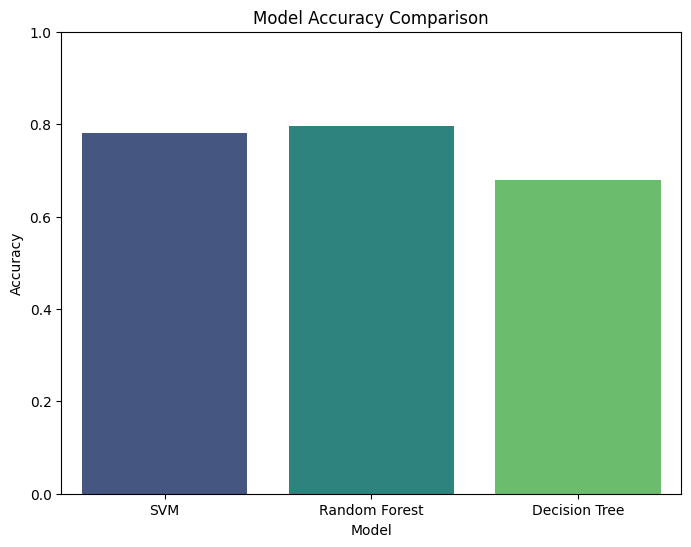

In [71]:
#comparison svm, rf and dt bar chart
accuracy_scores = {
    'Model': ['SVM', 'Random Forest', 'Decision Tree'],
    'Accuracy': [accuracy_test_svm, accuracy_test_rf, accuracy_test_dt]
}
accuracy_df = pd.DataFrame(accuracy_scores)

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()